In [2]:
# Montar Google Drive para acceder al dataset y guardar los modelos entrenados
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ---------------------------------------------------------------------------
# Importación de librerías
# ---------------------------------------------------------------------------
import os                                      # Manejo de rutas y directorios
import cv2                                     # Procesamiento de imágenes (OpenCV)
import numpy as np                             # Operaciones matriciales
import matplotlib.pyplot as plt               # Visualización de clusters
import pickle                                  # Serialización de modelos
from sklearn.decomposition import PCA          # Reducción de dimensionalidad
from sklearn.cluster import KMeans             # Algoritmo de clustering
from sklearn.metrics import silhouette_score, pairwise_distances  # Evaluación
from sklearn.preprocessing import StandardScaler  # Normalización Z-score
import shutil                                  # Copia de archivos al exportar muestras

In [4]:
# ---------------------------------------------------------------------------
# Función: extraer vector de features de una imagen usando histograma HSV
#
# Justificación matemática:
#   - Se convierte la imagen de BGR a HSV para separar información de color
#     (Hue), saturación (Saturation) y brillo (Value).
#   - Se calculan 32 bins por canal → vector final de 32 × 3 = 96 features.
#   - Los histogramas HSV son invariantes a cambios de iluminación y capturan
#     la distribución de color, que distingue tejido sano de tejido enfermo.
# ---------------------------------------------------------------------------

def extraer_features_hsv(ruta_imagen: str, bins: int = 32) -> np.ndarray:
    """
    Lee una imagen, la convierte a HSV y devuelve el histograma
    aplanado como vector de features de longitud bins * 3.

    Parámetros:
        ruta_imagen : ruta absoluta al archivo de imagen
        bins        : número de intervalos por canal (default: 32)

    Retorna:
        np.ndarray de shape (bins*3,) o None si la imagen no se puede leer
    """
    img = cv2.imread(ruta_imagen)
    if img is None:
        return None  # Imagen corrupta o ruta inválida

    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    histograma = []

    for canal in range(3):  # Canal 0: Hue, Canal 1: Saturation, Canal 2: Value
        hist = cv2.calcHist([img_hsv], [canal], None, [bins], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()  # Normalización L1 → suma = 1
        histograma.extend(hist)

    return np.array(histograma)


# ---------------------------------------------------------------------------
# Carga del dataset PlantVillage
# Se limita a MAX_POR_CLASE imágenes por clase para no saturar la RAM de Colab
# ---------------------------------------------------------------------------

DATASET_PATH = "/content/drive/MyDrive/RootKit/PlantVillage"
CLASES = sorted(os.listdir(DATASET_PATH))  # Lista ordenada de las 15 clases
MAX_POR_CLASE = 200                         # Muestreo controlado por clase

features_list = []   # Acumula vectores de features (96 dims cada uno)
etiquetas_list = []  # Acumula el índice numérico de la clase
rutas_list = []      # Acumula la ruta de cada imagen — sincronizado con X

for idx_clase, nombre_clase in enumerate(CLASES):
    ruta_clase = os.path.join(DATASET_PATH, nombre_clase)
    imagenes = os.listdir(ruta_clase)[:MAX_POR_CLASE]

    for nombre_img in imagenes:
        ruta_img = os.path.join(ruta_clase, nombre_img)
        feat = extraer_features_hsv(ruta_img)

        if feat is not None:  # Solo se agrega si la imagen es válida
            features_list.append(feat)
            etiquetas_list.append(idx_clase)
            rutas_list.append(ruta_img)  # Ruta guardada en el mismo orden que feat

# Convertir a arrays de NumPy para operaciones matriciales
X = np.array(features_list)  # Shape esperado: (n_muestras, 96)
y = np.array(etiquetas_list)

print(f"Shape del dataset de features: {X.shape}")
print(f"Clases encontradas: {len(CLASES)}")
print(f"Total de rutas registradas: {len(rutas_list)}")

Shape del dataset de features: (2952, 96)
Clases encontradas: 15
Total de rutas registradas: 2952


In [5]:
# ---------------------------------------------------------------------------
# Normalización Z-score
#
# Justificación: K-Means usa distancia euclidiana. Sin normalización, los
# canales con mayor varianza dominan el cálculo de distancias de forma
# artificial. StandardScaler lleva cada feature a media=0 y desv. std=1.
# ---------------------------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # fit_transform sobre el set completo

# ---------------------------------------------------------------------------
# Reducción de dimensionalidad con PCA a 50 componentes
#
# Justificación: PCA proyecta los 96 features originales a un subespacio
# ortogonal de 50 dimensiones que maximiza la varianza retenida. Esto:
#   1. Elimina correlaciones entre canales HSV
#   2. Reduce el ruido de features poco discriminantes
#   3. Acelera la convergencia de K-Means (maldición de la dimensionalidad)
# ---------------------------------------------------------------------------

pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

varianza_explicada = np.sum(pca.explained_variance_ratio_) * 100
print(f"Varianza explicada con 50 componentes: {varianza_explicada:.2f}%")

Varianza explicada con 50 componentes: 97.94%


In [6]:
# ---------------------------------------------------------------------------
# Búsqueda del k óptimo mediante Silhouette Score
#
# El Silhouette Score s(i) por muestra se define como:
#   s(i) = (b(i) - a(i)) / max(a(i), b(i))
#   donde:
#     a(i) = distancia media intra-cluster (cohesión)
#     b(i) = distancia media al cluster vecino más cercano (separación)
#
# El score global es el promedio de s(i) para todas las muestras.
# Rango: [-1, 1]. Valores cercanos a 1 indican clusters bien definidos.
# Se evalúan k = {5, 10, 15} y se selecciona el de mayor score.
# ---------------------------------------------------------------------------

valores_k = [5, 10, 15]
resultados_k = {}

for k in valores_k:
    km = KMeans(
        n_clusters=k,
        random_state=42,   # Reproducibilidad
        n_init=10,         # 10 inicializaciones aleatorias — se queda con la mejor
        max_iter=300       # Máximo de iteraciones por inicialización
    )
    km.fit(X_pca)

    # sample_size=2000 para acelerar el cálculo del score sin perder precisión
    score = silhouette_score(X_pca, km.labels_, sample_size=2000, random_state=42)
    resultados_k[k] = {"modelo": km, "silhouette": score}
    print(f"k={k:2d} | Silhouette Score: {score:.4f}")

# Selección automática del mejor k
mejor_k = max(resultados_k, key=lambda k: resultados_k[k]["silhouette"])
kmeans_final = resultados_k[mejor_k]["modelo"]
print(f"\nMejor k seleccionado: {mejor_k} (Silhouette: {resultados_k[mejor_k]['silhouette']:.4f})")

k= 5 | Silhouette Score: 0.0748
k=10 | Silhouette Score: 0.0729
k=15 | Silhouette Score: 0.0814

Mejor k seleccionado: 15 (Silhouette: 0.0814)


In [8]:
# ---------------------------------------------------------------------------
# Análisis semántico: clase dominante por cluster
#
# K-Means opera sobre features HSV sin conocer las etiquetas (y). Se usa
# el vector `y` (etiquetas verdaderas del dataset de entrenamiento) para
# hacer análisis post-hoc: identificar qué clase de PlantVillage representa
# la mayor proporción de muestras dentro de cada cluster.
#
# Resultado: cluster_semantica.pkl — diccionario exportado como artefacto
# { cluster_id: {"etiqueta": str, "clase_dominante": str,
#                "proporcion_dominante": float, "descripcion": str} }
# ---------------------------------------------------------------------------

import pandas as pd

# Nombres canónicos PlantVillage (mismo orden que CLASES, que usa sorted())
NOMBRES_CLASE = [
    "Pepper bell — Bacterial spot",
    "Pepper bell — Healthy",
    "Potato — Early blight",
    "Potato — Late blight",
    "Potato — Healthy",
    "Tomato — Bacterial spot",
    "Tomato — Early blight",
    "Tomato — Late blight",
    "Tomato — Leaf mold",
    "Tomato — Septoria leaf spot",
    "Tomato — Spider mites",
    "Tomato — Target spot",
    "Tomato — Yellow leaf curl virus",
    "Tomato — Mosaic virus",
    "Tomato — Healthy",
]

# Descripción orientada al usuario final para cada clase
DESCRIPCIONES_CLASE = {
    "Pepper bell — Bacterial spot":
        "Manchas acuosas con halo amarillo en pimiento. Agente: Xanthomonas campestris.",
    "Pepper bell — Healthy":
        "Hoja de pimiento sin patología detectada. Coloración uniforme.",
    "Potato — Early blight":
        "Lesiones circulares con anillos concéntricos en papa. Agente: Alternaria solani.",
    "Potato — Late blight":
        "Manchas irregulares oscuras en bordes de hoja de papa. Agente: Phytophthora infestans.",
    "Potato — Healthy":
        "Hoja de papa sin indicadores patológicos.",
    "Tomato — Bacterial spot":
        "Manchas pequeñas con borde irregular en tomate. Agente: Xanthomonas perforans.",
    "Tomato — Early blight":
        "Necrosis foliar con patrón concéntrico en tomate. Agente: Alternaria solani.",
    "Tomato — Late blight":
        "Daño severo en lámina foliar de tomate. Agente: Phytophthora infestans.",
    "Tomato — Leaf mold":
        "Manchas amarillas en el haz con micelio en el envés. Agente: Passalora fulva.",
    "Tomato — Septoria leaf spot":
        "Manchas circulares con centro blanco y borde oscuro. Agente: Septoria lycopersici.",
    "Tomato — Spider mites":
        "Moteado fino y decoloración por daño de Tetranychus urticae.",
    "Tomato — Target spot":
        "Lesiones necróticas concéntricas en tomate. Agente: Corynespora cassiicola.",
    "Tomato — Yellow leaf curl virus":
        "Enrollamiento y amarillamiento foliar. Agente: TYLCV (Begomovirus).",
    "Tomato — Mosaic virus":
        "Mosaico clorótico irregular. Agente: Tomato mosaic virus (ToMV).",
    "Tomato — Healthy":
        "Hoja de tomate sin patología detectada.",
}

# Construir DataFrame con cluster asignado y etiqueta verdadera
df_analisis = pd.DataFrame({
    "cluster_id":   kmeans_final.labels_,
    "clase_idx":    y,
    "clase_nombre": [NOMBRES_CLASE[i] for i in y],
})

# Calcular clase dominante y su proporción por cluster
cluster_semantica = {}

for cid in range(mejor_k):
    df_cluster = df_analisis[df_analisis["cluster_id"] == cid]

    conteo = df_cluster["clase_nombre"].value_counts()
    clase_dom = conteo.index[0]
    prop_dom  = conteo.iloc[0] / len(df_cluster)

    cluster_semantica[cid] = {
        "etiqueta":             clase_dom,
        "clase_dominante":      clase_dom,
        "proporcion_dominante": round(prop_dom, 4),
        "descripcion":          DESCRIPCIONES_CLASE.get(clase_dom, "Patrón visual identificado."),
    }

    print(f"Cluster {cid:2d} | {clase_dom:40s} | {prop_dom*100:.1f}% de las muestras")

MODELS_PATH = "/content/drive/MyDrive/RootKit/models"
os.makedirs(MODELS_PATH, exist_ok=True)

# Exportar el mapeo semántico como artefacto reutilizable
with open(f"{MODELS_PATH}/cluster_semantica.pkl", "wb") as f:
    pickle.dump(cluster_semantica, f)

print("\ncluster_semantica.pkl exportado correctamente.")

Cluster  0 | Tomato — Bacterial spot                  | 62.4% de las muestras
Cluster  1 | Potato — Early blight                    | 24.5% de las muestras
Cluster  2 | Pepper bell — Bacterial spot             | 46.6% de las muestras
Cluster  3 | Potato — Healthy                         | 19.2% de las muestras
Cluster  4 | Potato — Early blight                    | 70.9% de las muestras
Cluster  5 | Tomato — Healthy                         | 32.5% de las muestras
Cluster  6 | Pepper bell — Healthy                    | 45.8% de las muestras
Cluster  7 | Pepper bell — Bacterial spot             | 28.6% de las muestras
Cluster  8 | Tomato — Target spot                     | 19.2% de las muestras
Cluster  9 | Tomato — Yellow leaf curl virus          | 29.0% de las muestras
Cluster 10 | Potato — Late blight                     | 22.0% de las muestras
Cluster 11 | Tomato — Late blight                     | 100.0% de las muestras
Cluster 12 | Tomato — Leaf mold                       | 62.3% d

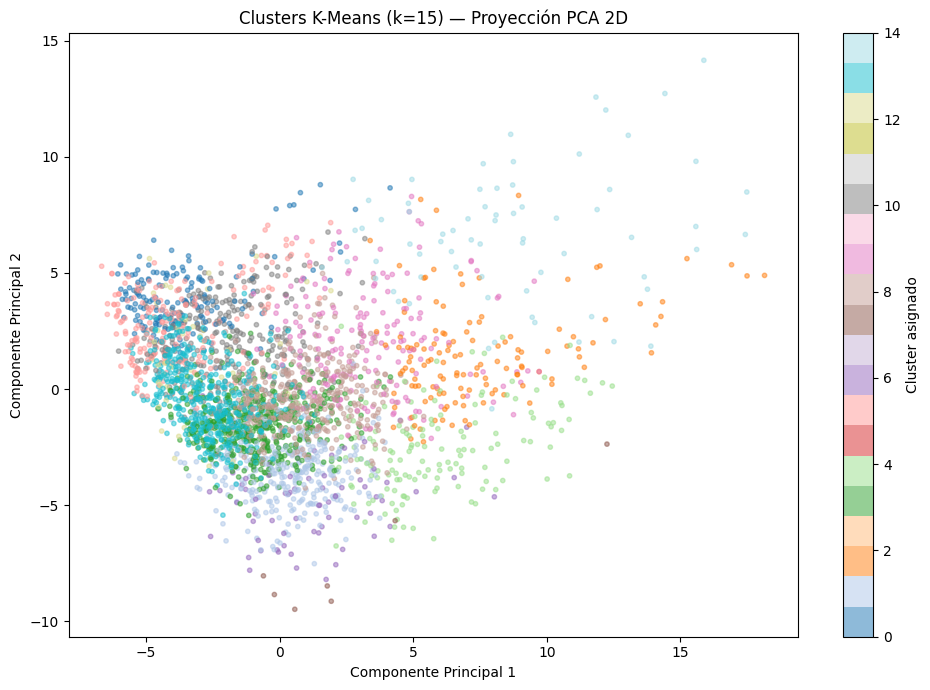

In [9]:
# ---------------------------------------------------------------------------
# Visualización de clusters en 2 dimensiones
#
# Se aplica una segunda reducción PCA a 2 componentes exclusivamente para
# graficar. Esta proyección es independiente del PCA de 50 componentes usado
# en el entrenamiento — no modifica los clusters, solo los proyecta en un
# plano visualizable.
# ---------------------------------------------------------------------------

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)  # Proyección desde X_scaled, no desde X_pca

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=kmeans_final.labels_,  # Color por cluster asignado
    cmap="tab20",
    alpha=0.5,
    s=10
)
plt.colorbar(scatter, label="Cluster asignado")
plt.title("Clusters K-Means (k=15) — Proyección PCA 2D")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.tight_layout()

# Guardar en Drive para incluir en el reporte
plt.savefig("/content/drive/MyDrive/RootKit/reports/kmeans_pca2d.png", dpi=150)
plt.show()

In [10]:
# ---------------------------------------------------------------------------
# Exportación de artefactos del pipeline de clustering
#
# Se guardan tres objetos independientes porque los tres son necesarios
# para reproducir la inferencia en la app web:
#   - clustering_scaler.pkl : normaliza la imagen nueva antes del PCA
#   - clustering_pca.pkl    : proyecta al espacio de 50 componentes
#   - clustering_kmeans.pkl : asigna el cluster final
# ---------------------------------------------------------------------------

MODELS_PATH = "/content/drive/MyDrive/RootKit/models"
os.makedirs(MODELS_PATH, exist_ok=True)

with open(f"{MODELS_PATH}/clustering_kmeans.pkl", "wb") as f:
    pickle.dump(kmeans_final, f)
    print("clustering_kmeans.pkl exportado")

with open(f"{MODELS_PATH}/clustering_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
    print("clustering_scaler.pkl exportado")

with open(f"{MODELS_PATH}/clustering_pca.pkl", "wb") as f:
    pickle.dump(pca, f)
    print("clustering_pca.pkl exportado")

print("\nTodos los modelos exportados correctamente en Drive/models/")

clustering_kmeans.pkl exportado
clustering_scaler.pkl exportado
clustering_pca.pkl exportado

Todos los modelos exportados correctamente en Drive/models/


In [11]:
# ---------------------------------------------------------------------------
# Exportación de imágenes representativas por cluster
#
# Para cada cluster se seleccionan las SAMPLES_POR_CLUSTER imágenes cuyo
# vector de features (en el espacio PCA de 50 dims) tiene menor distancia
# euclidiana al centroide del cluster. Estas imágenes son las más
# "típicas" de cada grupo y se usarán en la app como casos similares.
#
# Estructura de salida en Drive:
#   cluster_samples/
#       cluster_0/  sample_0.jpg ... sample_3.jpg
#       cluster_1/  sample_0.jpg ... sample_3.jpg
#       ...
#       cluster_14/ sample_0.jpg ... sample_3.jpg
# ---------------------------------------------------------------------------

# Verificar que rutas_list está sincronizado con X antes de copiar
assert len(rutas_list) == len(X), (
    f"Desincronización: {len(rutas_list)} rutas vs {len(X)} muestras en X"
)
print(f"Sincronización verificada: {len(rutas_list)} rutas — {len(X)} muestras")

SAMPLES_POR_CLUSTER = 4
OUTPUT_DIR = "/content/drive/MyDrive/RootKit/cluster_samples"

# Calcular distancia euclidiana de cada muestra a todos los centroides
centroides = kmeans_final.cluster_centers_          # Shape: (k, 50)
distancias = pairwise_distances(X_pca, centroides)  # Shape: (n_muestras, k)

for cluster_id in range(mejor_k):
    # Índices de las muestras que pertenecen a este cluster
    indices_cluster = np.where(kmeans_final.labels_ == cluster_id)[0]

    # Distancia de cada muestra del cluster a su propio centroide
    dist_al_centroide = distancias[indices_cluster, cluster_id]

    # Seleccionar las más cercanas al centroide (más representativas)
    top_indices = indices_cluster[np.argsort(dist_al_centroide)[:SAMPLES_POR_CLUSTER]]

    # Crear carpeta del cluster y copiar las imágenes seleccionadas
    carpeta = f"{OUTPUT_DIR}/cluster_{cluster_id}"
    os.makedirs(carpeta, exist_ok=True)

    for i, idx in enumerate(top_indices):
        shutil.copy(rutas_list[idx], f"{carpeta}/sample_{i}.jpg")

print(f"\nExportadas {SAMPLES_POR_CLUSTER} imágenes por cada uno de los {mejor_k} clusters.")
print(f"Carpeta destino: {OUTPUT_DIR}")

Sincronización verificada: 2952 rutas — 2952 muestras

Exportadas 4 imágenes por cada uno de los 15 clusters.
Carpeta destino: /content/drive/MyDrive/RootKit/cluster_samples
